### FFT Example from SciPy:
https://docs.scipy.org/doc/scipy/reference/tutorial/fft.html

In [1]:
#import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import scipy.fftpack
#import scipy.fft
import os
import csv
import re
import glob
import matplotlib.patches as patches

In [22]:
#generate Fourier spectrum map
def fourier_map(csv_fft):
    # output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier'
    # csv_filepath=os.path.join(output_path,'2020-07-01_14-41-11_chemotaxisl_worm2_fourierMap.csv')
    df=pd.read_csv(csv_fft, header=None)
    #plotting
    fig, ax = plt.subplots(figsize=(10,3))
    ax.imshow(df.iloc[:,0:519], extent=[0,xf[519],100,0], vmin=0, vmax=0.0025, aspect=0.2)#aspect=0.0025)#, cmap='Reds')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Body Segment')
    plt.title(re.split('/',csv_fft)[-1])
    #plt.savefig(re.split('.csv',csv_fft)[0]+'2.tiff',dpi=600)
    plt.show()
 

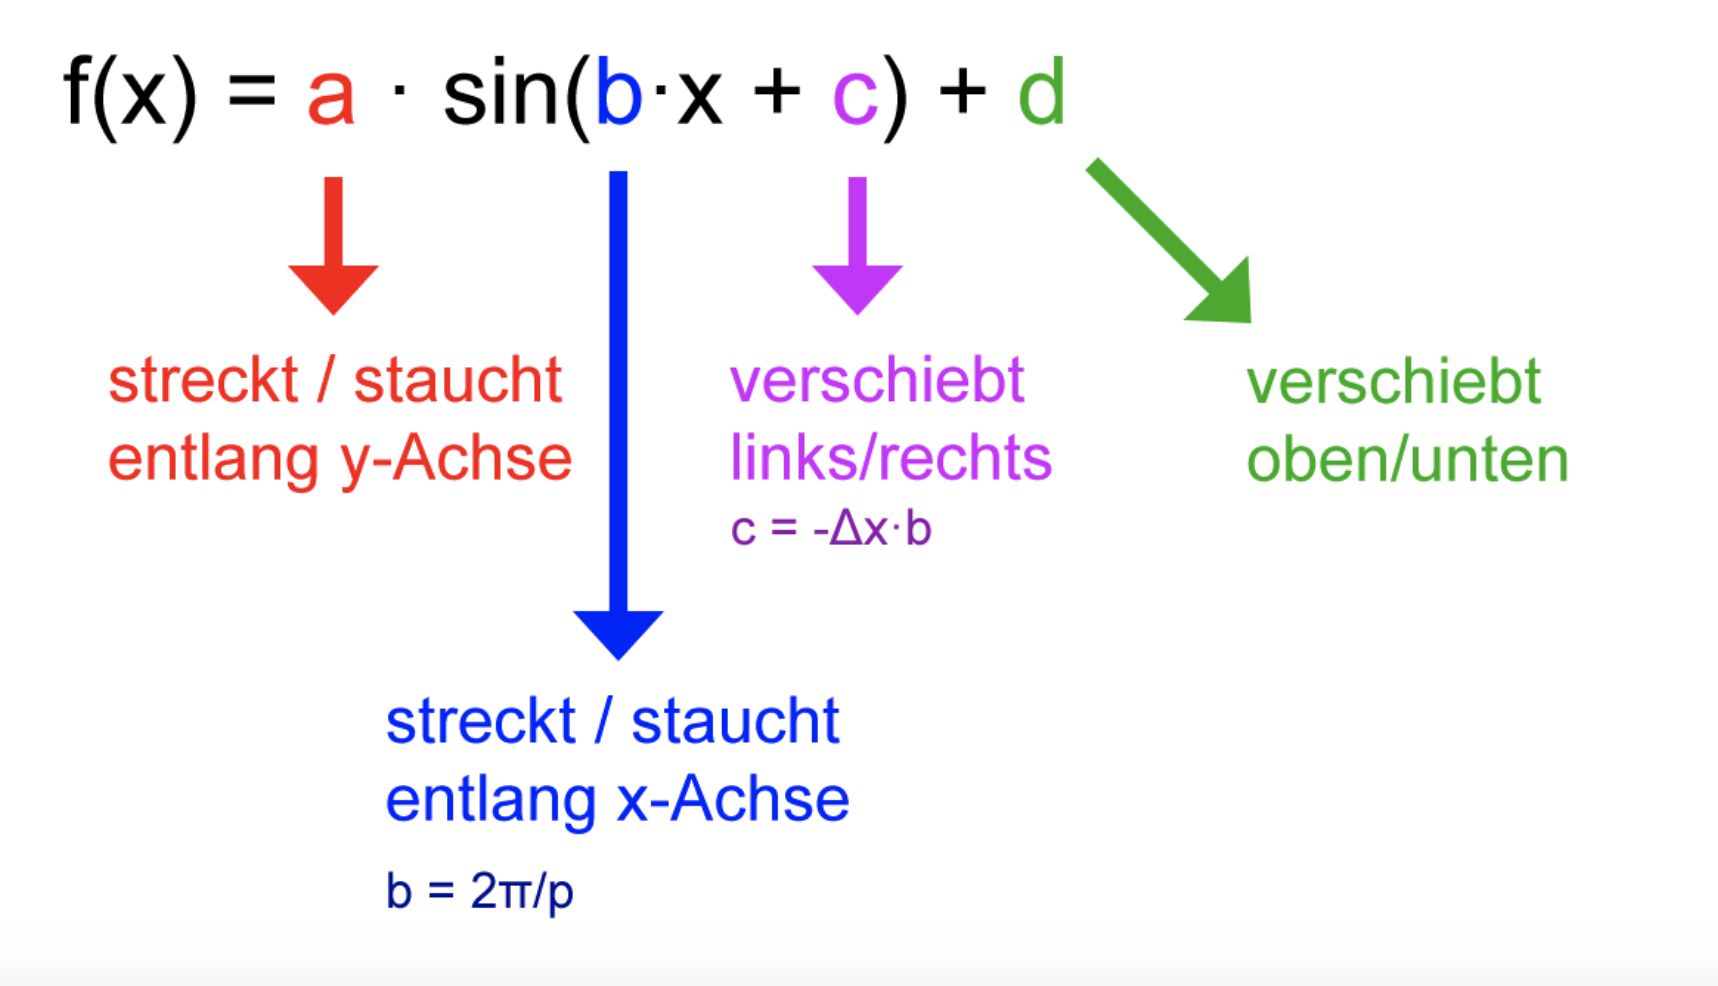

In [2]:
from fourier_functions import *
from coordinate_conversion_functions import *

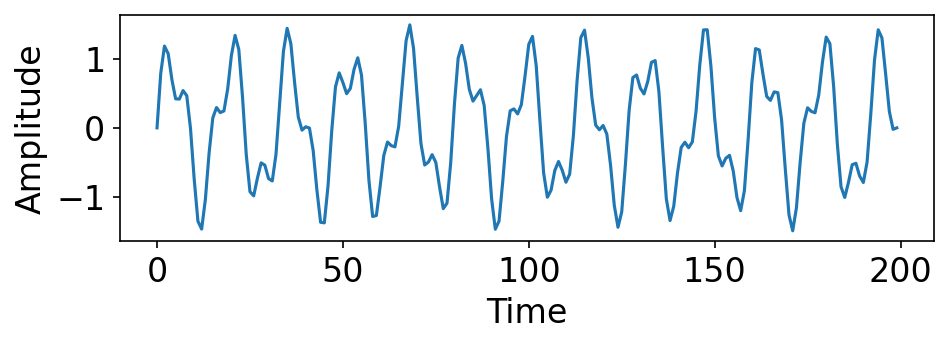

In [24]:
#this is the intial funciton constructed out of 2 sinoid functions y1 and y2 (see below)
N = 200 #number of samplepoints
# sample spacing
T = 1.0 / 800.0
x = np.linspace(0.0, N*T, N) #array from 0 to 0.25 with 200 values
y = np.sin(50.0 * 2*np.pi*x) + 0.5*np.sin(120.0 * 2.0*np.pi*x)

plt.figure(figsize=(7,2), dpi=150)
plt.plot(y)
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.show()

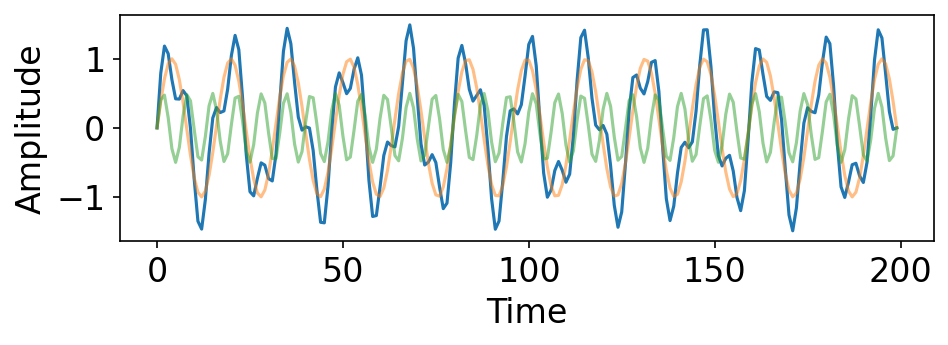

In [25]:
#composite and consitutive functions
y1= np.sin(50.0 * 2.0*np.pi*x)
y2= 0.5*np.sin(120.0 * 2.0*np.pi*x)
plt.figure(figsize=(7,2), dpi=150)
plt.plot(y)
plt.plot(y1, alpha=0.5)
plt.plot(y2, alpha=0.5)
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.show()

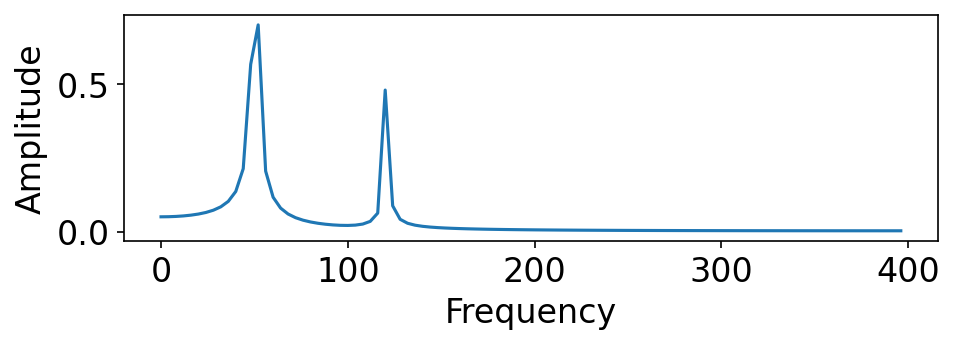

In [26]:
#here the fft does its magic
yf = scipy.fftpack.fft(y)
xf = scipy.fftpack.fftfreq(N, T)[:N//2]
fig, ax = plt.subplots(figsize=(7,2), dpi=150)
ax.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.ylabel('Amplitude')
plt.xlabel('Frequency')
plt.show()

# for all worms

In [44]:
#fourier transform  creates csv files of fourier maps for all worms
output_path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/fourier/all_fourier_good/'
path = '/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/*spline_K.csv'
for fname in glob.glob(path):
    #print (fname)
    #fourier_transform(fname,output_path)

2020-06-30_16-25-56_chemotaxis_wo
2020-06-30_17-47-20_chemotaxis_wo
2020-06-30_16-54-43_chemotaxis_wo
2020-07-01_14-41-11_chemotaxisl_wo
2020-07-01_13-21-00_chemotaxisl_wo
2020-07-01_10-50-18_control_wo
2020-07-01_15-42-06_chemotaxisl_wo
2020-06-30_18-17-47_chemotaxis_wo
2020-07-01_15-13-35_chemotaxisl_wo
2020-07-01_11-50-53_control_wo
2020-07-01_10-10-48_control_wo
2020-06-30_15-48-51_chemotaxis_wo
2020-07-01_16-20-36_chemotaxisl_wo
2020-07-01_17-32-12_control_wo
2020-07-01_17-58-13_control_wo
2020-07-01_17-01-27_chemotaxis_wo
2020-07-01_18-36-25_control_wo


In [ ]:
#fouriermap colorcode shows the amplitude for all worms
path = '/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/fourier/all_fourier_good/*.csv'
for fname in glob.glob(path):
    print (fname)
    fourier_map(fname)

# fourier for parts of tracks of single worms

In [74]:
#these are csvs i created with the head_position script 
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/head_tail_center_absolute_coordinates_x_ref_corrected/2020-07-01_14-41-11_chemotaxisl_worm2-TablePosRecord.csv'
df_head_tail_center_coords=pd.read_csv(path)

        Unnamed: 0          time  xc  x_center  yc  y_center  \
200000      200000  15:01:13.054   x   -0.0167   y   25.6224   

        x_head_corrected  y_head_corrected  x_tail_corrected  y_tail_corrected  
200000         -0.216298          26.14741          0.091606         25.105324  


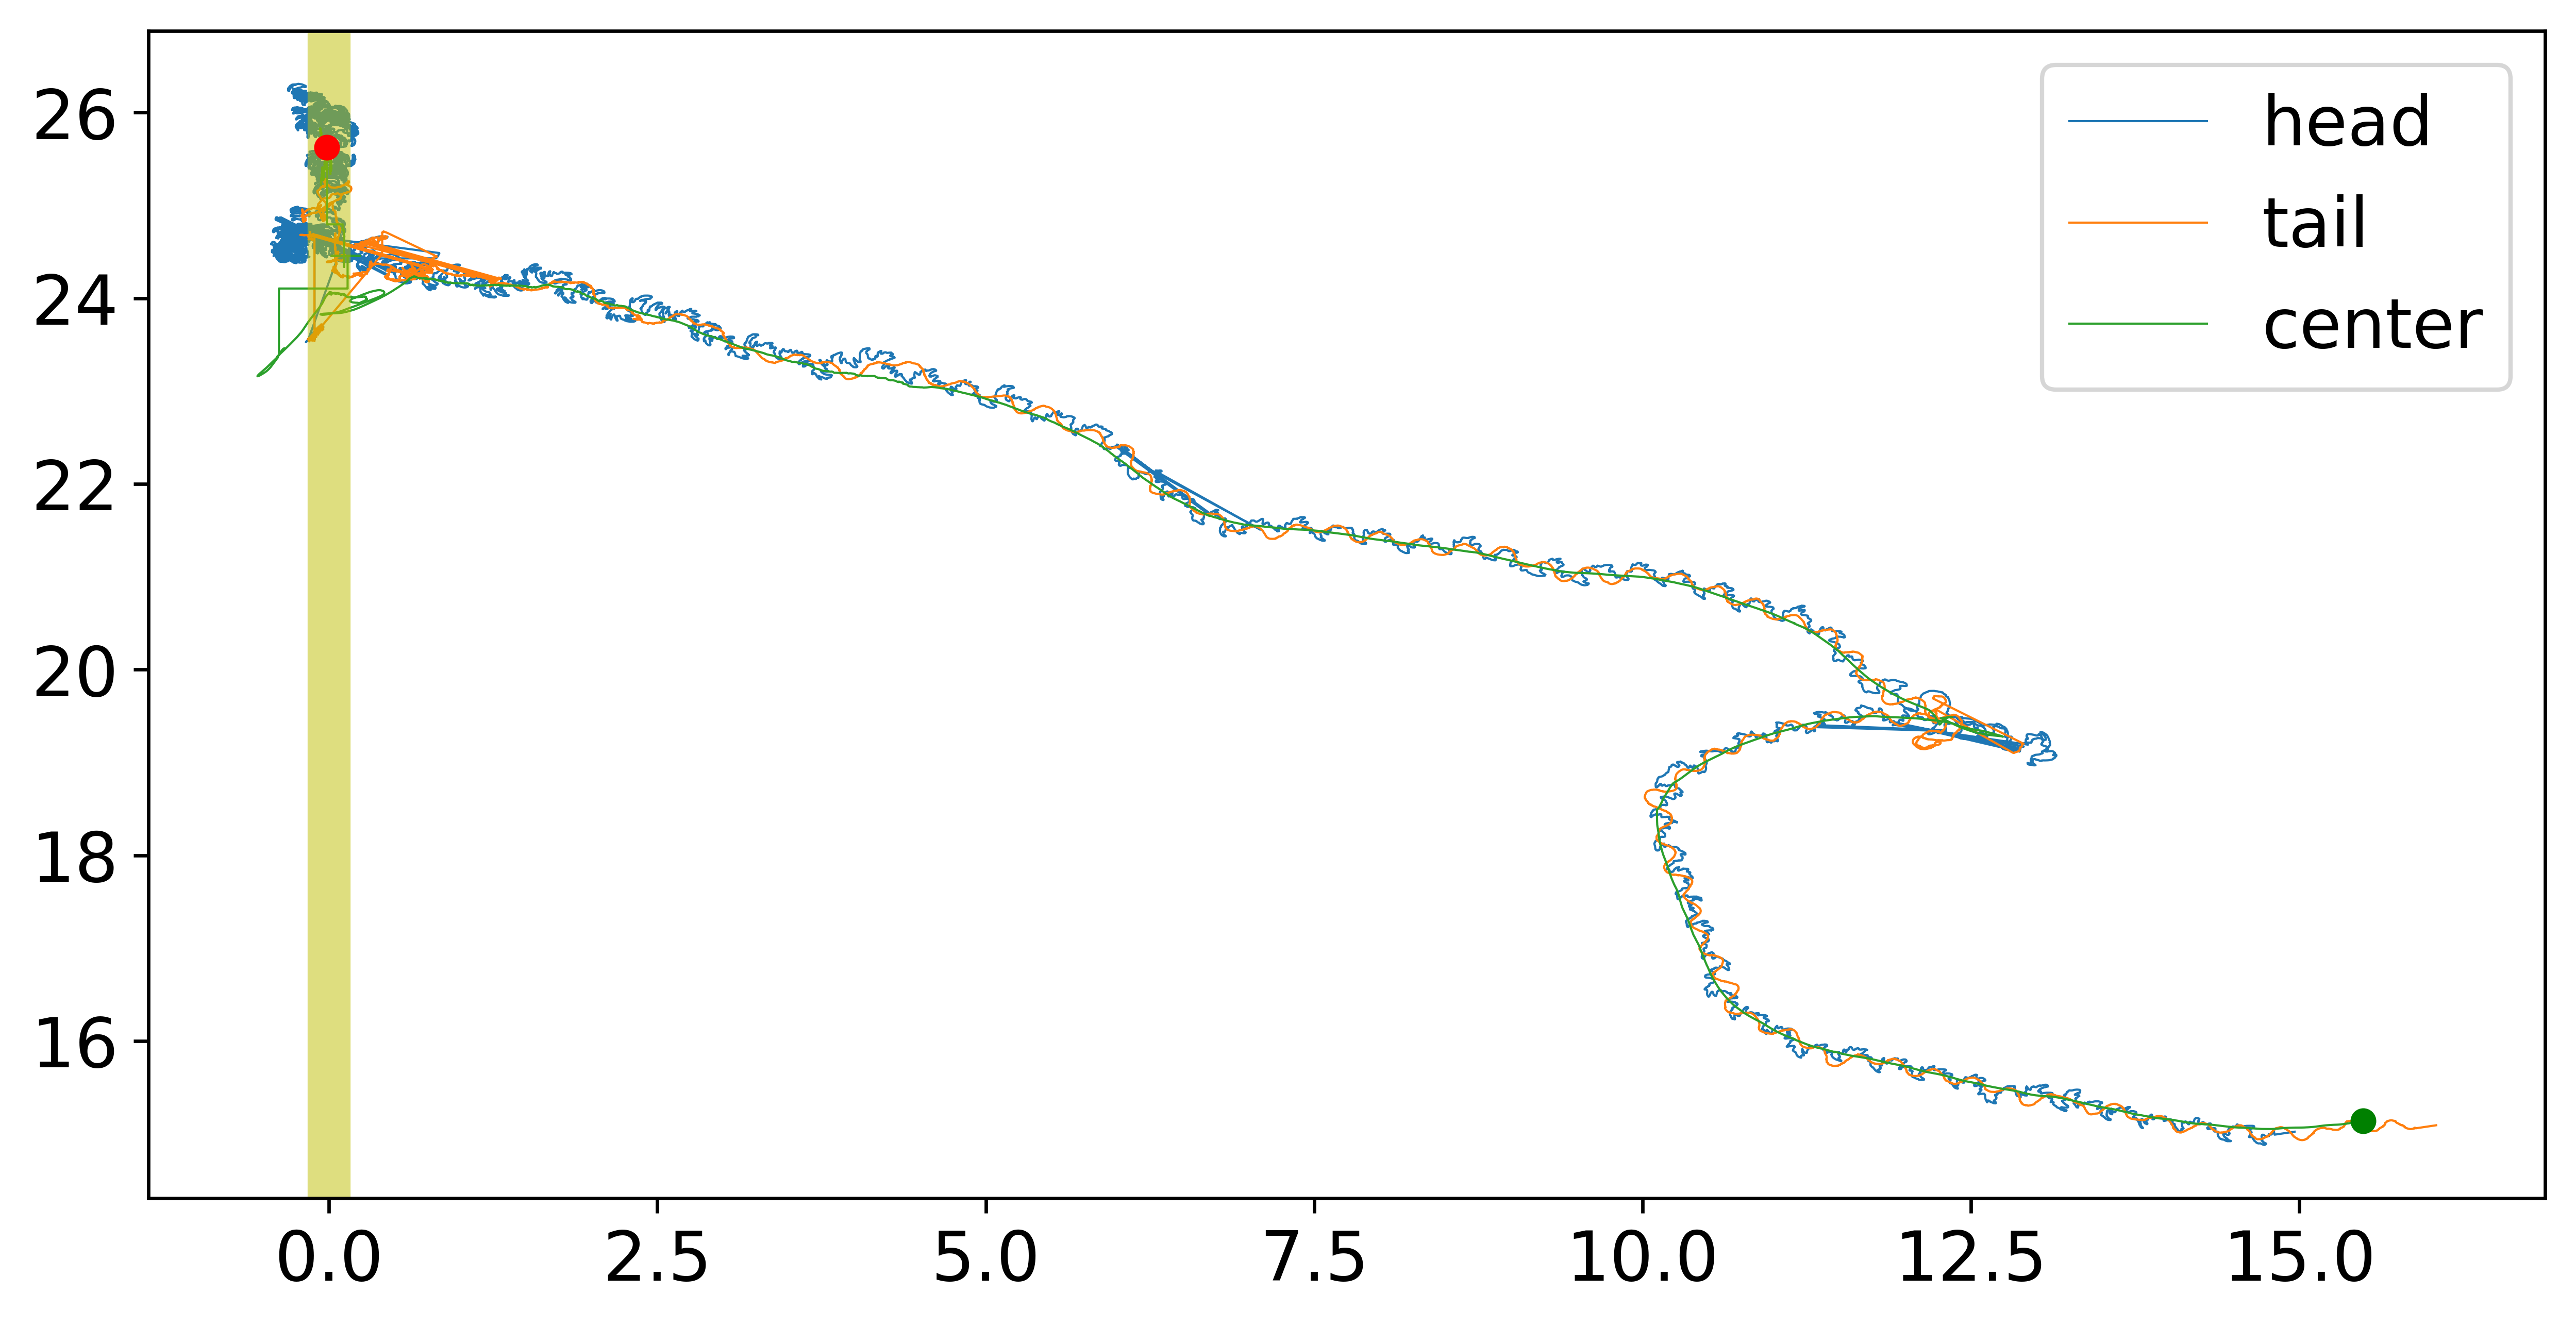

In [75]:
#plot the track to determine on which parts in want to do the fourier transformations
figsize_x=10
figsize_y=5
line_width=0.5
plot_tracks_center_head_tail(path,figsize_x,figsize_y,line_width)
  


In [76]:
#here i pull out timeframes where the worm is either awy form food chemotaxing or in the food, in order to compare 
#it with fourier transformation
away_from_food=df_head_tail_center_coords[(df_head_tail_center_coords['x_head_corrected'].between(11, 14)) & 
(df_head_tail_center_coords['y_head_corrected']< 18)]               
xmin_away=away_from_food['x_head_corrected'].min()
xmax_away=away_from_food['x_head_corrected'].max()
ymin_away=away_from_food['y_head_corrected'].min()
ymax_away=away_from_food['y_head_corrected'].max()

In [77]:
away_from_food

,Unnamed: 0,time,xc,x_center,yc,y_center,x_head_corrected,y_head_corrected,x_tail_corrected,y_tail_corrected
1696,1696,14:41:23.193,x,14.4887,y,15.0726,13.999205,15.150872,15.018303,14.932315
1697,1697,14:41:23.193,x,14.4881,y,15.0727,13.996597,15.149360,15.017949,14.932268
1698,1698,14:41:23.209,x,14.4874,y,15.0728,13.994600,15.148552,15.017249,14.932167
1699,1699,14:41:23.209,x,14.4867,y,15.0729,13.992257,15.146775,15.016550,14.932267
1700,1700,14:41:23.225,x,14.4861,y,15.0730,13.989861,15.145628,15.015950,14.932335
...,...,...,...,...,...,...,...,...,...,...
9600,9600,14:42:10.615,x,11.4097,y,15.9003,11.001833,16.120389,11.968714,15.773453
9601,9601,14:42:10.631,x,11.4095,y,15.9004,11.001516,16.120489,11.968628,15.774050
9602,9602,14:42:10.631,x,11.4091,y,15.9006,11.001116,16.120689,11.968229,15.774552
9603,9603,14:42:10.631,x,11.4088,y,15.9007,11.000748,16.120789,11.967929,15.774652


In [78]:
print(away_from_food.index.min())
print(away_from_food.index.max())

1696
9604


In [6]:
#plot the track to determine on which parts in want to do the fourier transformations
figsize_x=10
figsize_y=5
line_width=0.5
x_head_corrected=df_head_tail_center_coords['x_head_corrected']
y_head_corrected=df_head_tail_center_coords['y_head_corrected']
x_tail_corrected=df_head_tail_center_coords['x_tail_corrected']
y_tail_corrected=df_head_tail_center_coords['y_tail_corrected']
x_center_pos=df_head_tail_center_coords['x_center']
y_center_pos=df_head_tail_center_coords['y_center']
print(df_head_tail_center_coords.tail(1))
fig3, ax3 = plt.subplots(1,1, figsize = (figsize_x,figsize_y), dpi=600)
ax3.plot(x_head_corrected,y_head_corrected,label="head",linewidth=line_width)
ax3.plot(x_tail_corrected,y_tail_corrected,label="tail",linewidth=line_width)
ax3.plot(x_center_pos,y_center_pos,label="center",linewidth=line_width)
ax3.plot(df_head_tail_center_coords['x_center'][0],df_head_tail_center_coords['y_center'][0], 'go', markersize=5)
ax3.plot(df_head_tail_center_coords['x_center'].tail(1),df_head_tail_center_coords['y_center'].tail(1), 'ro', markersize=5)
xposition = [away_from_food['x_head_corrected'].min(), away_from_food['x_head_corrected'].max()]

rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=1, edgecolor='r', facecolor='none')
ax3.add_patch(rect)

ax3.legend()

NameError: name 'df_head_tail_center_coords' is not defined

# plotting a fourier spectrum map

In [4]:
#creates Fourier csv file
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/fourier/all_fourier/'
csv_skeleton='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
fourier_transform(csv_skeleton, path)

2020-07-01_14-41-11_chemotaxisl_wo


In [7]:
#these are the fourier transformed data
path='/groups/zimmer/shared_projects/DanielMitic/data/ulises_chemotaxis/fourier/all_fourier/2020-07-01_14-41-11_chemotaxisl_woFourierTransform.csv'
df=pd.read_csv(path)

In [8]:
#load data contains the curvature for each of 100 segments at each timepoint
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]
Kt=K.T
Kts=Kt[:,1696:9604]
N=Kts.shape[1]
#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)
xf=np.linspace(0.0, 1.0//(2.0*T), N//2)

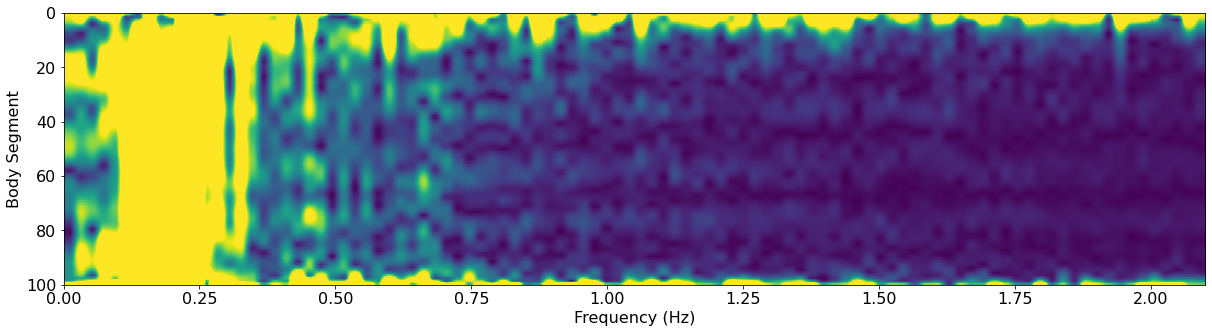

In [22]:
#generate Fourier spectrum map
fig, ax = plt.subplots(figsize=(50,5))
ax.imshow(df.iloc[:,0:100], extent=[0,xf[100],100,0], vmin=0, vmax=0.0025, aspect=0.005)#aspect=0.0025)#, cmap='Reds')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Body Segment')
#plt.title(re.split('/',csv_fft)[-1])
#plt.savefig(re.split('.csv',csv_fft)[0]+'2.tiff',dpi=600)
plt.show()

In [3]:
#load data
#csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_14-41-11_chemotaxisl_worm2_spline_K.csv'
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_17-01-27_chemotaxis_worm6_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]


In [4]:
win=5 #number of segments averaged (1 for single segments)
K_avg = pd.DataFrame(K) #convert to df to perform the groupy function
Kt_avg=K_avg.T
Kt_avg=Kt_avg.groupby(Kt_avg.index // win).mean() #takes the average of 5 segments resulting in 20 rows
print('number of rows and columns:'+str(Kt_avg.shape))
Kt_avg=Kt_avg.to_numpy() #converting df back to numpy array(otherwise fourier transformation makes problems
#Kt_avg

number of rows and columns:(20, 29793)


In [5]:
start_frame=1696
end_frame=9604
fps=167.0 #frames per second
Kt_avg=Kt_avg[:,start_frame:end_frame]
print(('lenght of recording:'+str((end_frame-start_frame)/fps)+" secs")) #defines the part of the track i want to fourier transform
print(Kt_avg.shape)

lenght of recording:47.35329341317365 secs
(20, 7908)


In [71]:
#modification of ulises fourier function
##made it more modular and added option to average over segments
def fourier_transform(Kts,fps,frequency_map,start_freq,end_freq):
    plt.rcParams.update({'figure.max_open_warning': 0})
    plt.rcParams.update({'font.size': 16})
    N=Kts.shape[1]
    #sample spacing
    T=1.0/fps
    #x=np.linspace(0.0, N*T, N)
    xf=np.linspace(0.0, 1.0//(2.0*T), N//2)


    for idx, segment in enumerate(Kts):
        #print(idx)
        #skip some segments
        #if idx%10!=5:continue
        #if idx >20:continue
    
        y=segment
        yf=scipy.fftpack.fft(y)
        #define axes
        #y_axis (see that it should start at 1 in yf[1:N//2])
        y_axis=2.0/N * np.abs(yf[1:N//2])
        #x_axis
        x_axis=xf[1:N//2]

        #define x and y
        x=np.arange(0, y[start_frame:end_frame].shape[0]/167,1/167)
        y=y[start_frame:end_frame]
    
        #plotting:
        plt.rcParams.update({'figure.max_open_warning': 0})
        plt.rcParams.update({'font.size': 16})
        #oscilations
        plt.figure(figsize=(20,3))
        plt.subplot(1,2,1)
        plt.plot(x,y)
        plt.title('Segment '+str((idx*win))+'-'+str(idx*win+win))
        if idx==0: plt.title('Segment '+str(idx)+'-'+str(win))
        plt.xlabel('Time (s)')
        plt.ylabel('Signal Amplitude (a.u)')
    
        #Frequency
        plt.subplot(1,2,2)
        plt.plot(x_axis, y_axis)
        plt.xticks(np.arange(start_freq, end_freq, step=1))
        plt.xlim(start_freq,end_freq)
        plt.title('Segment '+str((idx*win))+'-'+str(idx*win+win))
        if idx==0: plt.title('Segment '+str(idx)+'-'+str(win))
        plt.ylabel('Signal Amplitude (a.u)')
        plt.xlabel('Frequency (Hz)')
        
        #period
        #if frequency_map==1:
            #plt.subplot(1,3,3)
            #plt.plot(1/x_axis, y_axis)
            #plt.title('Signal Period at segment '+str((idx*win))+'-'+str(idx*win+win))
            #if idx==0: plt.title('Signal Period at Segment '+str(idx)+'-'+str(win))
            #plt.xlabel('Period (s)')
            #plt.ylabel('Signal Amplitude (a.u)')
        #else:
            #frequecy map
            #plt.subplot(1,3,3)
            #y_img=np.tile(y_axis, (500, 1))
            #plt.imshow(y_img[1:100,0:100], extent=[0.5,xf[300],500,0], vmin=0, vmax=0.025, aspect=0.0015)
            #plt. yticks(y," ")
            #plt.xlabel('Frequency (Hz)')
            #plt.title('Segment '+str((idx*win))+'-'+str(idx*win+win))
            #if idx==0: plt.title('Segment '+str(idx)+'-'+str(win))
        plt.savefig(str(idx)+'.png')
        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, hspace=0.3)
            

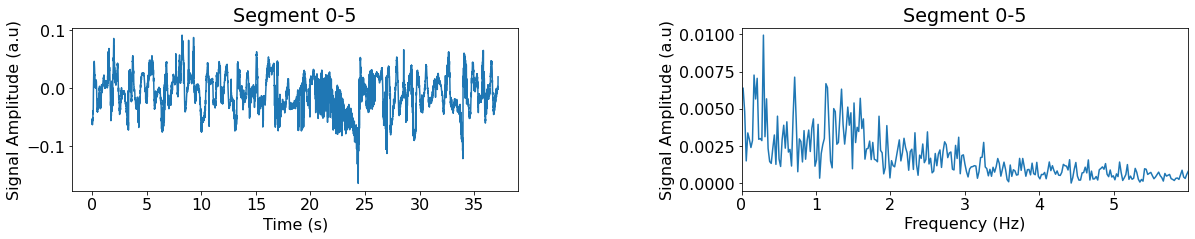

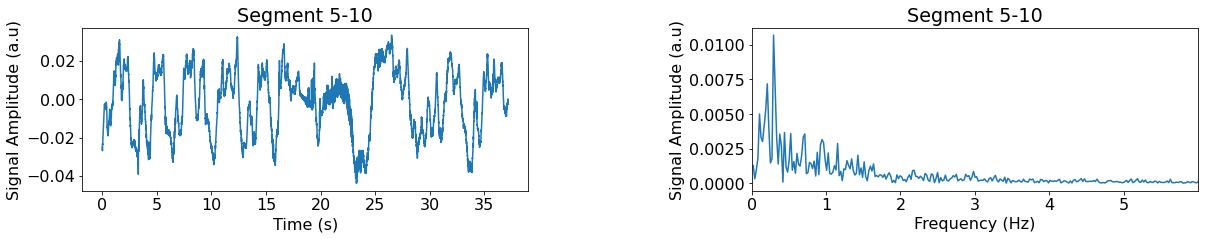

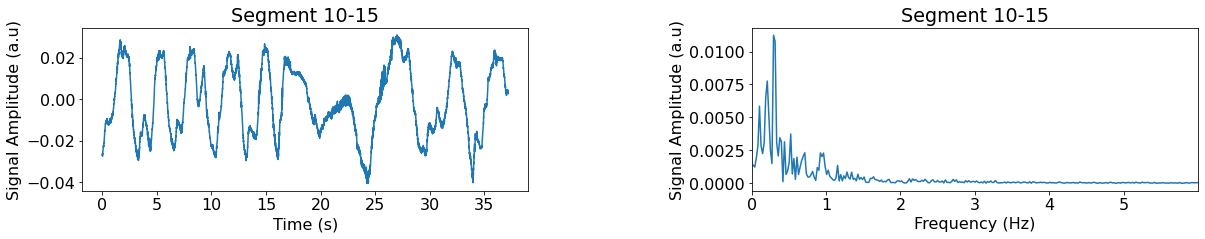

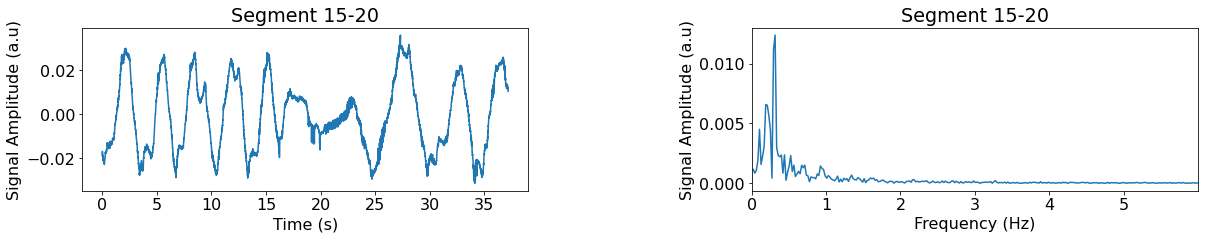

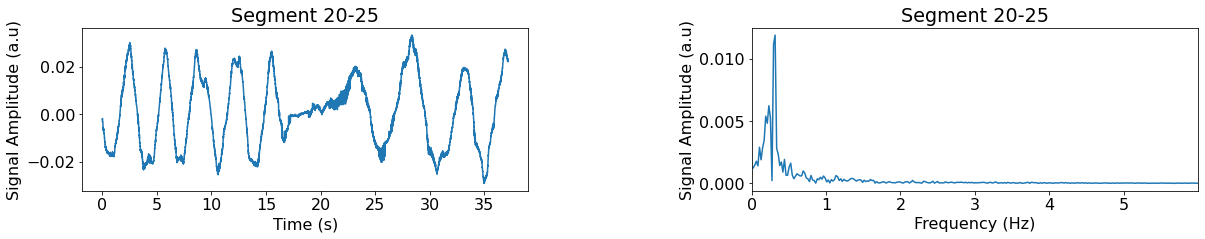

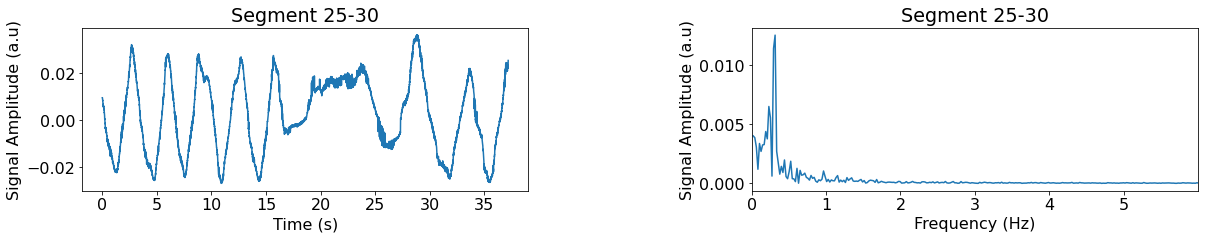

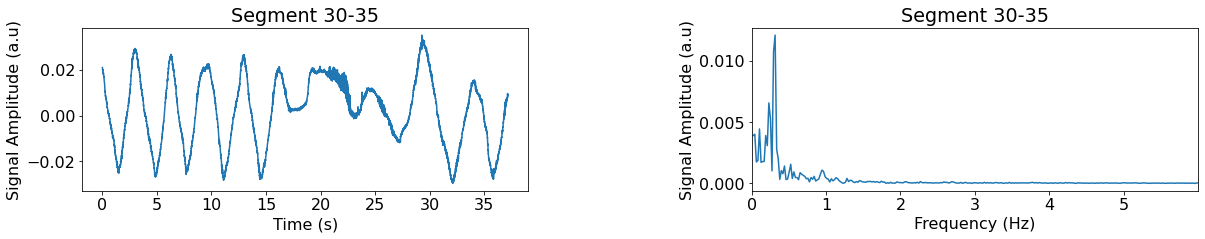

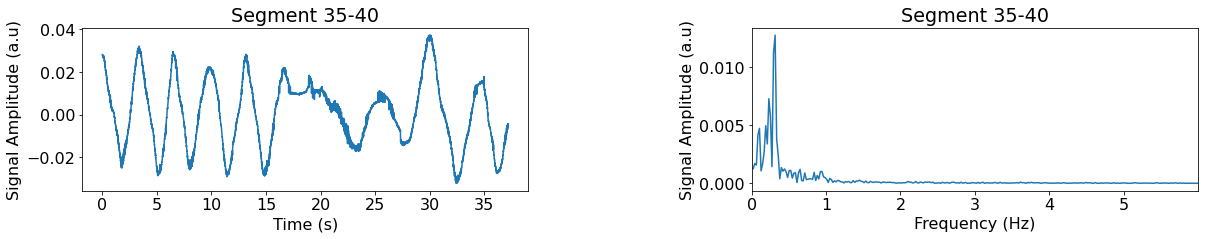

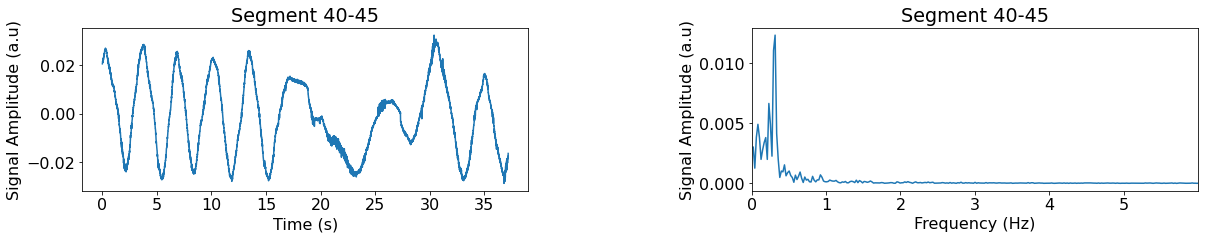

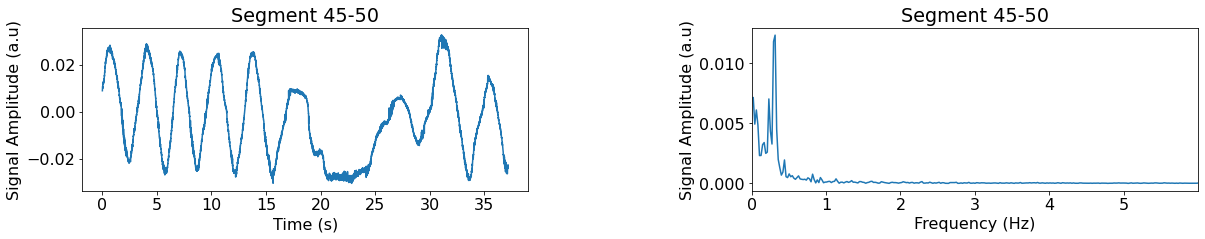

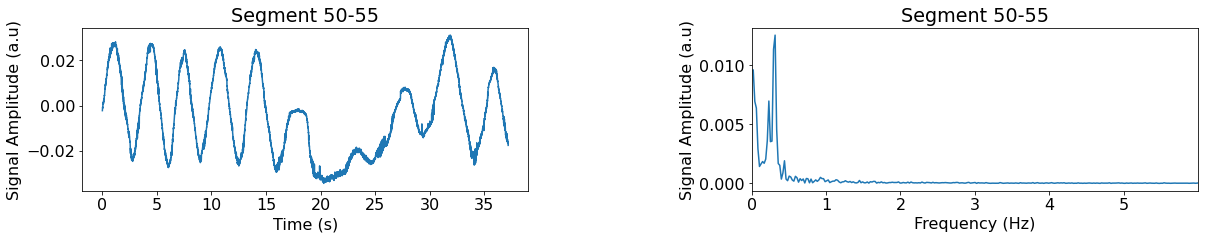

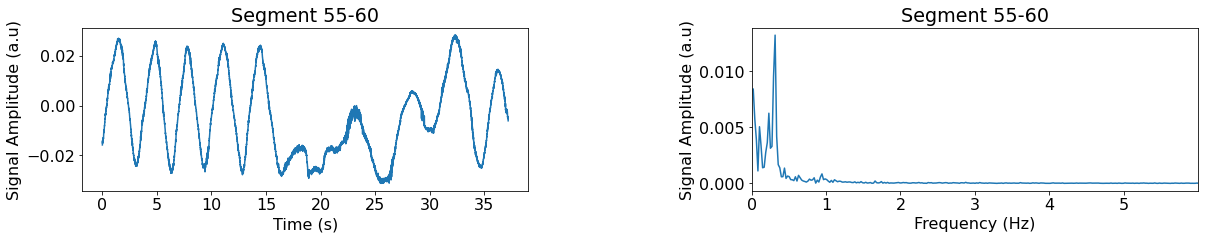

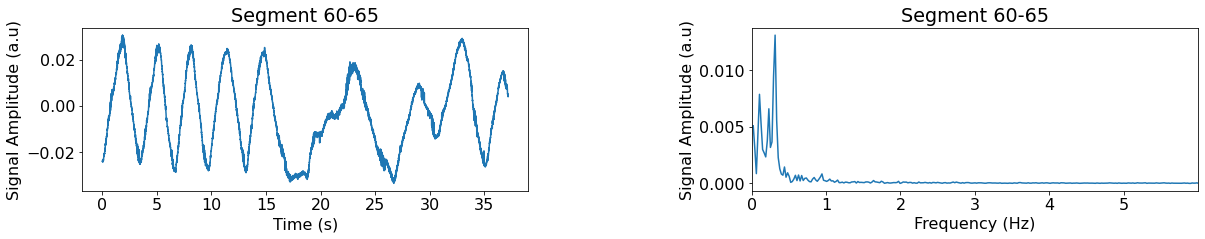

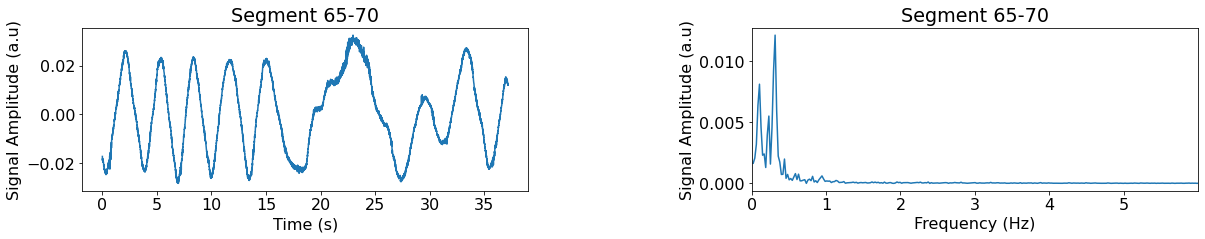

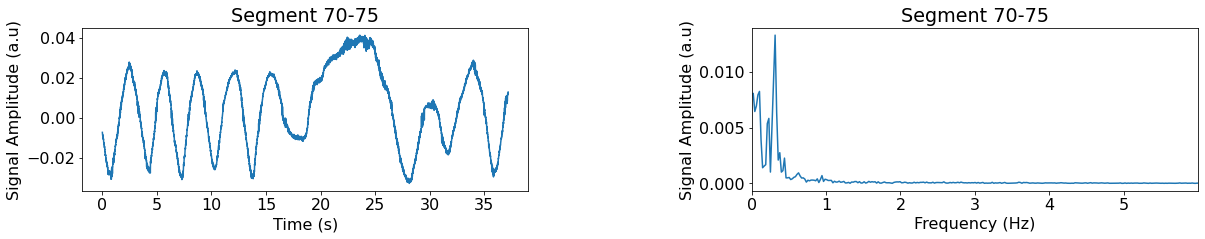

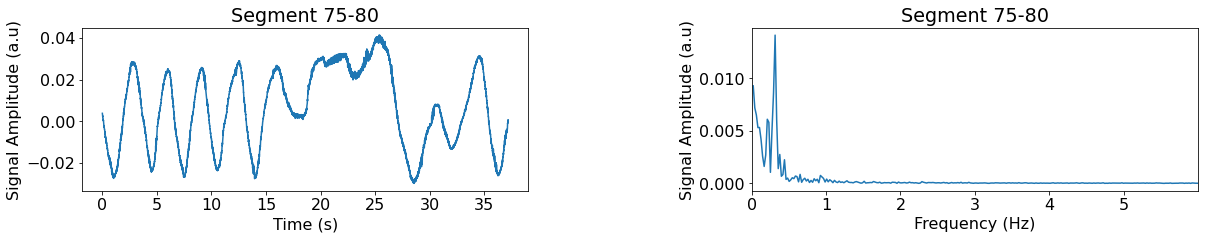

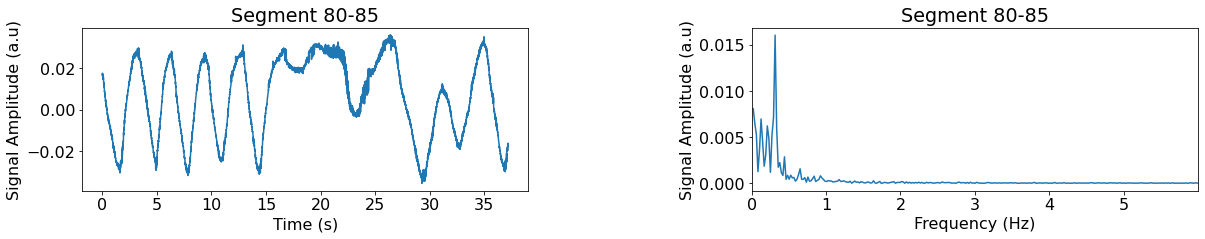

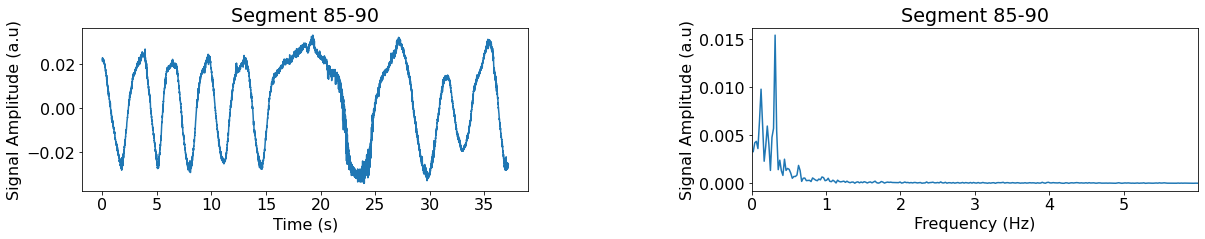

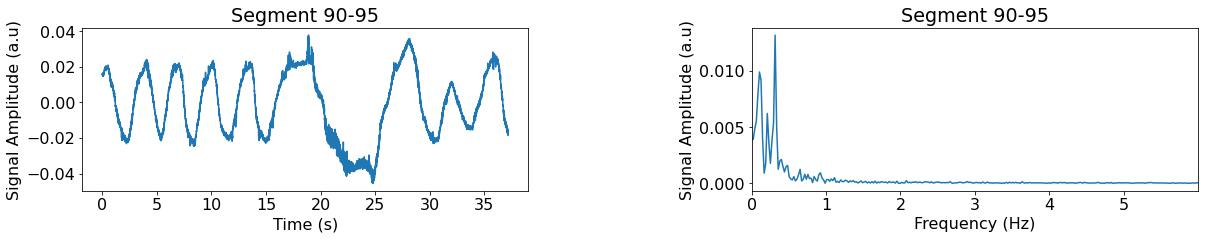

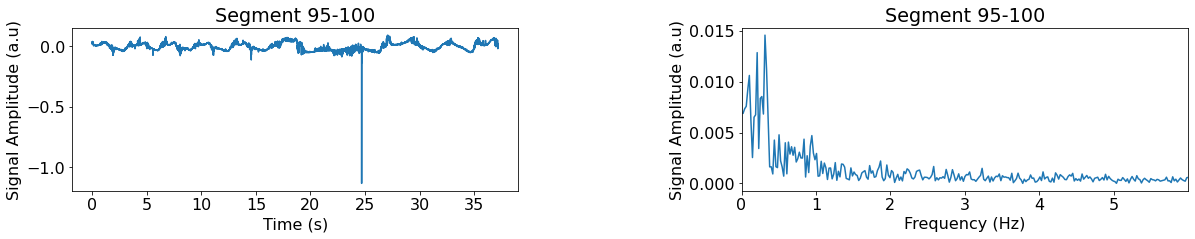

In [72]:
start_frame=1696
end_frame=9604
frequency_map=0
start_freq=0 #range of requencys which should be displayed
end_freq=6 #range of requencys which should be displayed
fps=167.0 #frames per second
fourier_transform(Kt_avg,fps,frequency_map,start_freq,end_freq)

In [80]:
fps

167.0

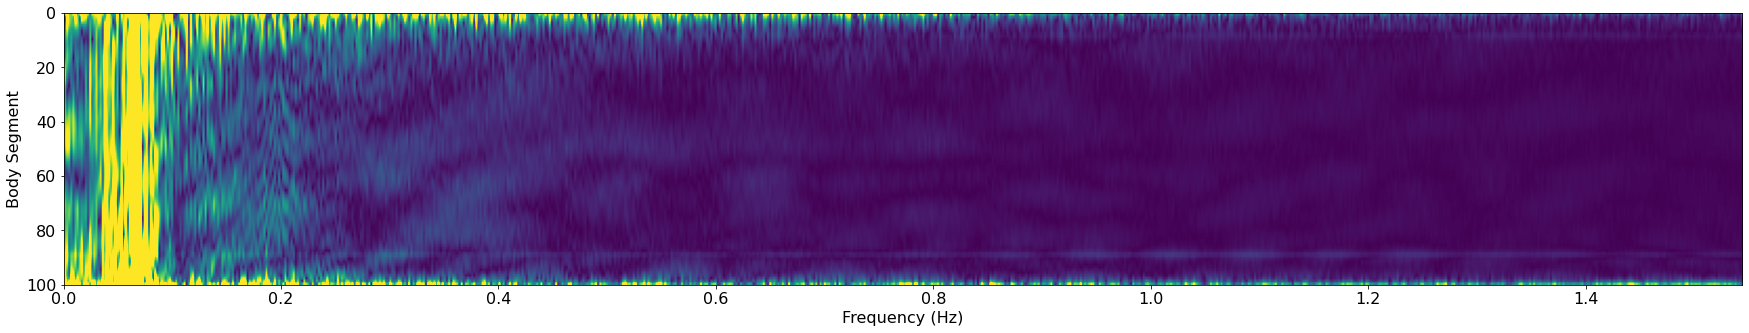

In [ ]:
#this shows the curvature for each segment
#define plot and axis
start=5
stop=600
fps=167
x_axis=np.linspace(start,stop,num=(stop-start)*fps) #array from 5 to 600 with 99365 values(99365=number of seconds *frames per second-->number of frames in recording)

for idx, segment in enumerate(Kt):
    #define which body segments to show
    if idx%50!=5: continue
    fig=plt.figure(figsize=(6,2))
    plt.plot(x_axis,segment[start*fps:stop*fps])
    plt.title('Body Segment '+str(idx))
    plt.xlabel('Time (s)')
    plt.ylabel('K (Curvature)')
    plt.show()
#    break